# Refraction raypath examples for layered limestone and cave model

This notebook builds two clean raypath figures using the current geometry and layer properties:

1. **Snell's-law example** — piecewise-straight rays that refract at layer and cave boundaries. The red ray is a head wave and the blue ray is a constrained ray that passes through the cave; both arrive at the same geophone.
2. **Fermat's-principle example** — compares the travel time of a ray forced through the slow cave with the least-time head-wave path that avoids it.

A third reference figure shows the same layered model without the cave. The previous orange ray has been removed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import minimize

# =============================================================================
# Model and geometry from the latest working cell
# =============================================================================

vp_layers = np.array([1000.0, 3350.0, 4750.0])     # P-wave velocities [m/s]
thicknesses = np.array([10.0, 25.0, 45.0])        # Layer thicknesses [m]
densities = np.array([2000.0, 2275.0, 2450.0])    # Density [kg/m^3]
z_nodes = np.array([0.0, 10.0, 35.0, 80.0])       # Interface depths [m]

layer_names = [
    "Unsaturated limestone",
    "Saturated limestone\n30% porosity",
    "Saturated limestone\nlow porosity",
]

# Cave parameters: 20 m × 20 m, centred at x=0 m and depth=22.5 m
cave_v = 1500.0
cave_w = 20.0
cave_h = 20.0
cave_x1, cave_x2 = -10.0, 10.0
cave_z1, cave_z2 = 12.5, 32.5

# Example source and receiver/geophone.
# The red head wave and blue cave-crossing ray both terminate at this receiver.
src_x = -120.0
rec_x = 75.0

xlim = (-150.0, 150.0)
zlim = (80.0, 0.0)


In [2]:
def draw_velocity_profile(ax):
    """Draw the 1D blocky P-wave velocity model."""
    v_plot = [vp_layers[0], vp_layers[0], vp_layers[1], vp_layers[1], vp_layers[2], vp_layers[2]]
    z_plot = [z_nodes[0], z_nodes[1], z_nodes[1], z_nodes[2], z_nodes[2], z_nodes[3]]

    ax.plot(v_plot, z_plot, color="black", linewidth=2.5)
    ax.set_xlim(0, 5500)
    ax.set_ylim(z_nodes[-1], 0)
    ax.set_xlabel("P-wave velocity [m/s]", fontweight="bold")
    ax.set_ylabel("Depth [m]", fontweight="bold")
    ax.set_title("1D velocity model", fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.5)

    for i in range(3):
        z_mid = 0.5 * (z_nodes[i] + z_nodes[i + 1])
        ax.text(
            vp_layers[i] - 150,
            z_mid,
            f"Layer {i+1}\nVp={vp_layers[i]:.0f} m/s\nρ={densities[i]:.0f} kg/m³",
            ha="right",
            va="center",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.75, boxstyle="round,pad=0.3"),
        )


def draw_layered_model(ax, show_cave=True):
    """Draw the layered cross-section, optional cave, source, and receiver."""
    colors = ["#fff1cf", "#dff1dc", "#dcecff"]

    for i in range(3):
        z0, z1 = z_nodes[i], z_nodes[i + 1]
        ax.add_patch(
            patches.Rectangle(
                (xlim[0], z0),
                xlim[1] - xlim[0],
                z1 - z0,
                facecolor=colors[i],
                edgecolor="0.45",
                linewidth=0.8,
            )
        )
        ax.text(
            xlim[0] + 6,
            0.5 * (z0 + z1),
            f"{layer_names[i]}\nVp = {vp_layers[i]:.0f} m/s",
            ha="left",
            va="center",
            fontsize=9,
        )

    for z in z_nodes[1:-1]:
        ax.axhline(z, color="black", linestyle="--", linewidth=1, alpha=0.7)

    if show_cave:
        cave = patches.Rectangle(
            (cave_x1, cave_z1),
            cave_w,
            cave_h,
            facecolor="#9ecae1",
            edgecolor="black",
            linewidth=1.8,
            hatch="//",
            zorder=4,
        )
        ax.add_patch(cave)
        ax.text(
            0,
            0.5 * (cave_z1 + cave_z2),
            f"Cave\n{cave_w:.0f} × {cave_h:.0f} m\nVp = {cave_v:.0f} m/s",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            zorder=5,
        )

    # Shot and receiver symbols
    ax.plot(src_x, 0, marker="*", markersize=14, color="red", markeredgecolor="black", zorder=10)
    ax.plot(rec_x, 0, marker="v", markersize=10, color="royalblue", markeredgecolor="black", zorder=10)
    ax.text(src_x, -2.5, "shot", color="red", ha="center", va="bottom", fontsize=9)
    ax.text(rec_x, -2.5, "geophone", color="royalblue", ha="center", va="bottom", fontsize=9)

    ax.set_xlim(*xlim)
    ax.set_ylim(*zlim)
    ax.set_xlabel("x [m]", fontweight="bold")
    ax.set_ylabel("Depth [m]", fontweight="bold")
    ax.grid(True, alpha=0.15)


def plot_ray(ax, xs, zs, color, label, lw=2.5, linestyle="-", zorder=8):
    """Plot a piecewise-linear ray and add direction arrows along segments."""
    xs = np.asarray(xs, dtype=float)
    zs = np.asarray(zs, dtype=float)
    ax.plot(xs, zs, color=color, linewidth=lw, linestyle=linestyle, label=label, zorder=zorder)

    for i in range(len(xs) - 1):
        x0, z0 = xs[i], zs[i]
        x1, z1 = xs[i + 1], zs[i + 1]
        xm = x0 + 0.62 * (x1 - x0)
        zm = z0 + 0.62 * (z1 - z0)
        dx = 0.12 * (x1 - x0)
        dz = 0.12 * (z1 - z0)
        ax.annotate(
            "",
            xy=(xm + dx, zm + dz),
            xytext=(xm, zm),
            arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=12),
            zorder=zorder + 1,
        )


In [3]:
def head_wave_path(src_x, rec_x):
    """Return the piecewise-linear head wave refracted along the top of layer 3."""
    # Head wave along the 35 m interface. Ray parameter p = 1 / V3.
    p_head = 1.0 / vp_layers[2]
    theta1 = np.arcsin(p_head * vp_layers[0])  # angle from vertical normal in layer 1
    theta2 = np.arcsin(p_head * vp_layers[1])  # critical angle in layer 2

    dx1 = thicknesses[0] * np.tan(theta1)
    dx2 = thicknesses[1] * np.tan(theta2)
    xcrit = dx1 + dx2

    horizontal_leg = (rec_x - src_x) - 2.0 * xcrit
    if horizontal_leg <= 0:
        raise ValueError("Source-receiver offset is too short for a layer-3 head wave.")

    xs = [
        src_x,
        src_x + dx1,
        src_x + xcrit,
        rec_x - xcrit,
        rec_x - dx1,
        rec_x,
    ]
    zs = [0.0, z_nodes[1], z_nodes[2], z_nodes[2], z_nodes[1], 0.0]

    travel_time = (
        np.hypot(dx1, thicknesses[0]) / vp_layers[0]
        + np.hypot(dx2, thicknesses[1]) / vp_layers[1]
        + horizontal_leg / vp_layers[2]
        + np.hypot(dx2, thicknesses[1]) / vp_layers[1]
        + np.hypot(dx1, thicknesses[0]) / vp_layers[0]
    )

    return np.asarray(xs), np.asarray(zs), travel_time


def cave_crossing_ray_path(src_x, rec_x):
    """
    Find a least-time path constrained to pass through the cave.

    The path is piecewise-straight in each velocity region:
    source -> z=10 interface -> left cave wall -> right cave wall -> z=10 interface -> receiver.
    Optimizing the interface/wall crossing points gives a Snell-like path while ensuring
    the ray passes through the void.
    """
    def travel_time(p):
        x_top_left, z_left, z_right, x_top_right = p

        pts = np.array([
            [src_x, 0.0],
            [x_top_left, z_nodes[1]],
            [cave_x1, z_left],
            [cave_x2, z_right],
            [x_top_right, z_nodes[1]],
            [rec_x, 0.0],
        ])

        speeds = np.array([vp_layers[0], vp_layers[1], cave_v, vp_layers[1], vp_layers[0]])
        seg_lengths = np.sqrt(np.sum(np.diff(pts, axis=0) ** 2, axis=1))
        return np.sum(seg_lengths / speeds)

    bounds = [
        (src_x, cave_x1),
        (cave_z1, cave_z2),
        (cave_z1, cave_z2),
        (cave_x2, rec_x),
    ]

    # Initial path roughly through the cave centre.
    x0 = [-35.0, 22.5, 22.5, 35.0]
    res = minimize(travel_time, x0=x0, bounds=bounds, method="Nelder-Mead")

    # Re-run with L-BFGS-B if Nelder-Mead wanders near bounds.
    if not res.success:
        res = minimize(travel_time, x0=x0, bounds=bounds, method="L-BFGS-B")

    x_top_left, z_left, z_right, x_top_right = [float(v) for v in res.x]

    xs = np.array([src_x, x_top_left, cave_x1, cave_x2, x_top_right, rec_x], dtype=float)
    zs = np.array([0.0, z_nodes[1], z_left, z_right, z_nodes[1], 0.0], dtype=float)

    return xs, zs, float(travel_time(res.x))


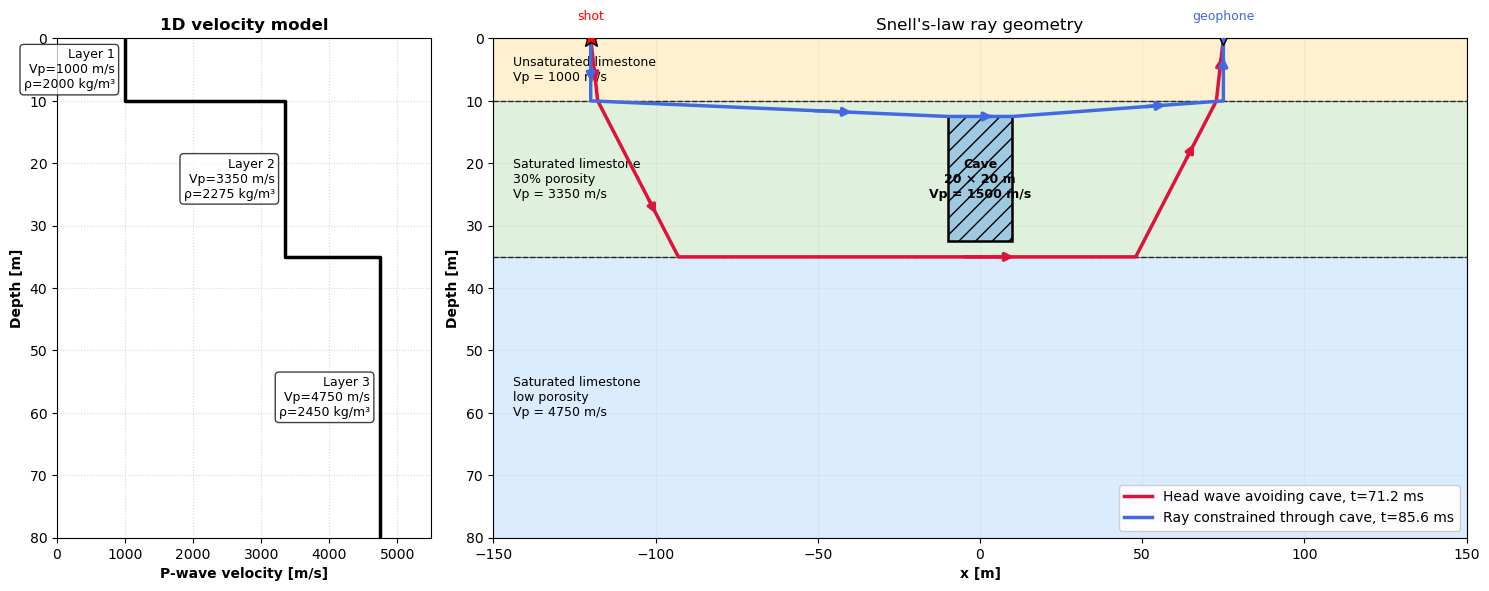

Head-wave travel time:        71.19 ms
Cave-crossing travel time:   85.59 ms
Cave path delay:             14.41 ms


In [4]:
# =============================================================================
# Snell's-law example: head wave and cave-transmitted ray to the same geophone
# =============================================================================

head_x, head_z, t_head = head_wave_path(src_x, rec_x)
cave_x, cave_z, t_cave = cave_crossing_ray_path(src_x, rec_x)

fig, (ax_v, ax) = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.0, 2.6]},
)

draw_velocity_profile(ax_v)
draw_layered_model(ax, show_cave=True)

plot_ray(
    ax,
    head_x,
    head_z,
    color="crimson",
    label=f"Head wave avoiding cave, t={t_head*1000:.1f} ms",
)
plot_ray(
    ax,
    cave_x,
    cave_z,
    color="royalblue",
    label=f"Ray constrained through cave, t={t_cave*1000:.1f} ms",
)

ax.set_title("Snell's-law ray geometry")
ax.legend(loc="lower right", framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"Head-wave travel time:        {t_head*1000:.2f} ms")
print(f"Cave-crossing travel time:   {t_cave*1000:.2f} ms")
print(f"Cave path delay:             {(t_cave - t_head)*1000:.2f} ms")


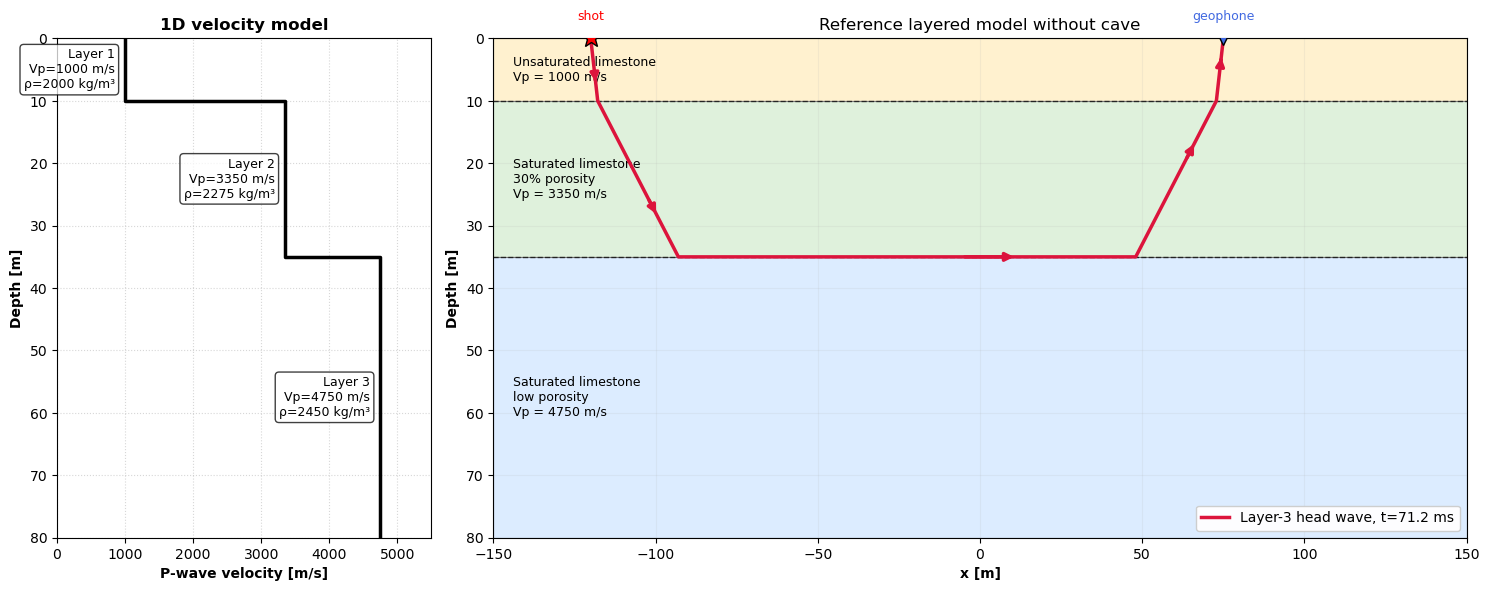

In [5]:
# =============================================================================
# Reference model without cave: red head wave only; no orange ray
# =============================================================================

fig, (ax_v, ax) = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.0, 2.6]},
)

draw_velocity_profile(ax_v)
draw_layered_model(ax, show_cave=False)

plot_ray(
    ax,
    head_x,
    head_z,
    color="crimson",
    label=f"Layer-3 head wave, t={t_head*1000:.1f} ms",
)

ax.set_title("Reference layered model without cave")
ax.legend(loc="lower right", framealpha=0.95)
plt.tight_layout()
plt.show()


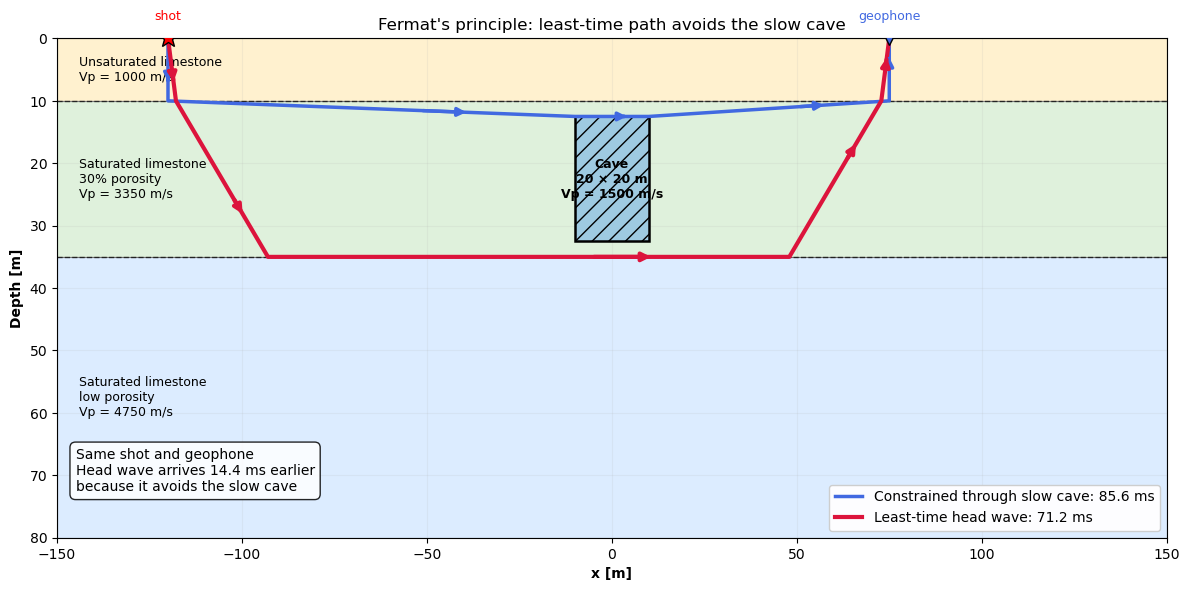

In [6]:
# =============================================================================
# Fermat's-principle example
# =============================================================================
# Fermat's principle says the first arrival follows the path of least travel time,
# not the shortest geometric path. Here the cave-crossing path is constrained to
# pass through a slow body, whereas the head wave spends more distance in fast
# lower limestone and therefore arrives earlier.

fig, ax = plt.subplots(figsize=(12, 6))
draw_layered_model(ax, show_cave=True)

plot_ray(
    ax,
    cave_x,
    cave_z,
    color="royalblue",
    label=f"Constrained through slow cave: {t_cave*1000:.1f} ms",
    lw=2.5,
)
plot_ray(
    ax,
    head_x,
    head_z,
    color="crimson",
    label=f"Least-time head wave: {t_head*1000:.1f} ms",
    lw=3.0,
)

ax.set_title("Fermat's principle: least-time path avoids the slow cave")
ax.legend(loc="lower right", framealpha=0.95)

annotation = (
    f"Same shot and geophone\n"
    f"Head wave arrives {(t_cave - t_head)*1000:.1f} ms earlier\n"
    f"because it avoids the slow cave"
)
ax.text(
    -145,
    73,
    annotation,
    ha="left",
    va="bottom",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.85, boxstyle="round,pad=0.4"),
)

plt.tight_layout()
plt.show()
